# Call ROH from WGS data and bam input
Uses more than the 1240k SNPs - the input now are all SNPs in 1000G with >5%MAF. That allows for ROH calls in aDNA WGS data down to ~0.1x coverage

In [1]:
### First some Standard Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os as os
import sys as sys
import multiprocessing as mp
print(f"CPU Count: {mp.cpu_count()}")

### If you want to use a version other than the default installed hapROH 
### uncomment the following and set the path to the correct (installed) package
#sys.path.insert(0,"/mnt/archgen/users/hringbauer/git/hapROH/package/")  # Uncomment to get local package first in path

CPU Count: 128


# 1) Prepare the input data
First, we need to generate an eigenstrat file with the 1000G SNPs.

We begin by defining the input and output paths - you can adjust them to your use case. The input .bam should be a processed one, e.g. the one that one would use to call pseudo-haploid genotypes. This is usually the last stage of your processing pipeline.

The function below grabs the SNP set from the MAF 5% reference panel (path_h5) and produces a matching eigenstrat genotype file from your .bam.

## [Download test data]
To run this test, you can download the necessary example data and reference panel:
- WGS example .bam file: Use [this Dropbox folder](https://www.dropbox.com/scl/fo/9wqnhka1clwduaf375oyy/AOXi2b-3BshPXTeoaCTjMOQ?rlkey=ipc3b53ryjreruta8r6d40a4q&st=v9u8360n&dl=0). This data is ~0.15x Coverage, below the cutoff of classical hapROH with 1240k SNPs!
- Reference data for >5% MAF WGS data [this Dropbox folder](https://www.dropbox.com/scl/fo/i0s02rgh7m76fnhakkqg4/AEZLpJGvU6R6Tll6DtW9vp8?rlkey=c6ribb29mq46sgkcmdw7eojwu&st=y4hcd0du&dl=0)

In [4]:
# 1000G reference panel with MAF 5% (you can download this from ...)
path_h5 = "/mnt/archgen/users/yilei/Data/1000G/1000g1240khdf5/all1240/maf5_auto/maf5_chr"   

### Specific Target
path_bam = "./ExampleData/wgs/SB606.merged.rg.markdup.indrealn_recalibrated.bam" # Update to the example data!
sample_name = "SB606" # The iid of your sample (to use in hapROH output)
path_eigenstrat = f"/mnt/archgen/users/hringbauer/data/med_jews/es/maf5_1kg_{sample_name}" # path to the output, without file extension

folder_roh_out = '/mnt/archgen/users/hringbauer/data/med_jews/roh/'

### 1a) Prepare eigenstrat file

In [3]:
from hapROH.IO.prep_input import bam2eigenstrat

In [4]:
%%time
bam2eigenstrat(path_bam, sample_name, 
               path_out=path_eigenstrat, path_h5=path_h5)     # takes around 3-5min

Done !
Output written to SB606.snp/.ind/.geno
CPU times: user 21.4 s, sys: 2.35 s, total: 23.8 s
Wall time: 3min 15s


# 2) Run hapROH with WGS ref panel
Now that the eigenstrat file is prepared, you can run hapROH on it using the 1000G reference panel (with 5% MAF cutoff).

In [2]:
from hapsburg.PackagesSupport.hapsburg_run import hapsb_ind
from hapsburg.figures.plot_posterior import plot_posterior_cm

In [5]:
%%time
hapsb_ind(iid=sample_name, chs=range(1,23), 
           path_targets=path_eigenstrat, # The path before the .ind, .snp, .geno
           h5_path1000g=path_h5, # The path up to the chr. number
           meta_path_ref="/mnt/archgen/users/yilei/Data/1000G/1000g1240khdf5/all1240/meta_df_all.csv", 
           folder_out=folder_roh_out,  # Folder where you want to save the results to 
           processes=4, output=True,
           readcounts=False, logfile=True, combine=True)

Doing Individual SB606...
Set Output Log path: /mnt/archgen/users/hringbauer/data/med_jews/roh/SB606/chr7/hmm_run_log.txtSet Output Log path: /mnt/archgen/users/hringbauer/data/med_jews/roh/SB606/chr5/hmm_run_log.txtSet Output Log path: /mnt/archgen/users/hringbauer/data/med_jews/roh/SB606/chr1/hmm_run_log.txtSet Output Log path: /mnt/archgen/users/hringbauer/data/med_jews/roh/SB606/chr3/hmm_run_log.txt



Combining Information for 22 Chromosomes...
CPU times: user 56.1 ms, sys: 115 ms, total: 171 ms
Wall time: 5min 11s


,Start,End,StartM,EndM,length,lengthM,iid,ch,StartPosGRCh37,EndPosGRCh37
0,6,807,0.022045,0.071066,801,0.049021,SB606,1,830181,3289971
0,51360,54807,1.774683,1.934886,3447,0.160203,SB606,3,171188929,183215541
0,37312,40049,1.333614,1.428496,2737,0.094882,SB606,7,124372827,134802683
0,12465,16801,0.577467,0.693488,4336,0.116021,SB606,13,60134112,74070376
0,8185,9053,0.534855,0.587118,868,0.052263,SB606,17,32355361,35207263
0,1060,2332,0.099496,0.211470,1272,0.111974,SB606,19,2965238,6793829


# 3) Make a plot of the inferred ROH

In [8]:
from hapsburg.figures.plot_individual_roh import plot_roh_individual

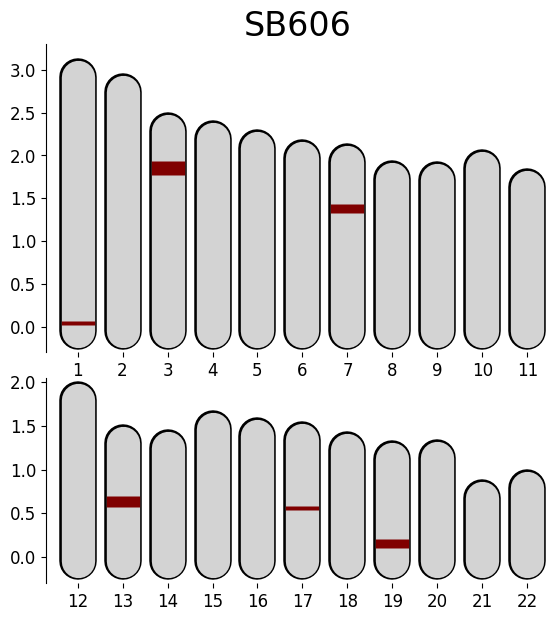

In [9]:
plot_roh_individual(iid=sample_name, folder="/mnt/archgen/users/hringbauer/data/med_jews/roh/", figsize=(6.5, 7),
                    prefix_out="", min_cm=4, plot_bad=False, savepath="") 

So we successfully found multiple ROH! This plot is as expected, as from this indivdual also a higher coverage version exists, which shows the same ROH. Congratulations on running hapROH for WGS samples!